# 2 - Training U-Net for Gap-Filling (Generic - Streaming)

**Self-supervised streaming training pipeline** for any Level-3 ocean variable.

This notebook trains a U-Net to fill gaps in satellite ocean observations using **xbatcher streaming** to keep memory bounded. Works for:
- Chlorophyll-a (PACE, Copernicus, CMEMS)
- Sea surface temperature
- Any other gridded ocean variable with cloud/missing data

## Key Features

- **Streaming workflow**: Zarr → xarray/Dask → xbatcher → TensorFlow
- **Memory-bounded**: Never loads full dataset into RAM
- **Spatial chunking**: 40×56 tiles (or configurable)
- **Generic target variable**: Not hardcoded to chlorophyll
- **Self-supervised**: No gap-free truth needed  
- **Synthetic clouds**: Temporally-correlated fake gaps for training/eval

## Workflow

```
Zarr (on-disk)
  ↓ xr.open_zarr with chunks
Lazy xarray/Dask Dataset
  ↓ prepare_model_data (crops to U-Net multiple, no .load())
Lazy standardized channels
  ↓ xbatcher.BatchGenerator
Spatial tiles (time × 40×56)
  ↓ make_tf_gen → tf.data.Dataset
Training batches
  ↓
model.fit()
```

## Setup

### packages

In [1]:
%pip install -e ..

%load_ext autoreload
%autoreload 2

Obtaining file:///home/jovyan/mindthegap
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for mindthegap (pyproject.toml) ... done
  Created wheel for mindthegap: filename=mindthegap-0.2.0-0.editable-py3-none-any.whl size=5715 sha256=e865114bcf3a94bc5f438f24c806f1c4a6bb6dc8f77ef0c6af2f5ddc1e8048fe
  Stored in directory: /tmp/pip-ephem-wheel-cache-1esyb1sn/wheels/bf/33/56/bda8a265cbf6abb8b49f20ef4e8f99a5cafc428b704405201e
Successfully built mindthegap
  Attempting uninstall: mindthegap
    Found existing installation: mindthegap 0.2.0
    Uninstalling mindthegap-0.2.0:
      Successfully uninstalled mindthegap-0.2.0
Note: you may need to restart the kernel to use updated packages.


In [2]:
!pip install -qU "icechunk>=2" "earthaccess>=0.15"

In [4]:
!pip install -qU boto3 botocore s3transfer

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
awscli 1.45.58 requires botocore==1.43.58, but you have botocore 1.43.67 which is incompatible.
aiobotocore 2.25.2 requires botocore<1.40.71,>=1.40.46, but you have botocore 1.43.67 which is incompatible.


## 0. Set-up

smoke_test propagates the fast-run settings (few epochs) into options.fit.

In [1]:
# Copilot: Create mtg.set_up(smoke_test=False)
# this just runs this. Later functions will check that options is created

# Copilot: mtg.set_up() should load the packages and check for GPU
### all the stuff below
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"  # Reduce TensorFlow verbosity

import numpy as np
import pandas as pd
import xarray as xr
import tensorflow as tf
import matplotlib.pyplot as plt
import mindthegap as mtg

# TensorFlow automatically uses CPU when no GPU is available.
gpus = tf.config.list_physical_devices("GPU")
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

print(f"TensorFlow version: {tf.__version__}")
print(f"Compute device: {'GPU' if gpus else 'CPU'}")
print(f"GPUs available: {len(gpus)}")

2026-08-14 22:47:57.997354: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1786747678.017776   63212 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1786747678.024270   63212 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1786747678.039586   63212 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1786747678.039609   63212 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1786747678.039611   63212 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.1
Compute device: GPU
GPUs available: 1


In [2]:
options = mtg.Options.default(smoke_test=False)


## 1. Load Your Data

Load your xarray Dataset with **time, lat, lon** dimensions.

### Requirements:
- Target variable (e.g., `chlor_a`, `sst`, `analysed_sst`)
- Cloud/missing flag variable (1 = cloud/missing, 0 = valid data)
- Land flag variable (1 = land, 0 = ocean)
- Optional: Additional predictor variables (SST, winds, salinity, etc.)

### Data Source Examples:

In [8]:
# This is some other examples of data you could load
dataset = "globcolour"  # pace, globcolour, indian-ocean, or synthetic
region = "arabian sea"  # or [lat_min, lat_max, lon_min, lon_max]
time_slice = None

dataset = "indian-ocean"  # pace, globcolour, indian-ocean, or synthetic
region = "indian ocean"  # or [lat_min, lat_max, lon_min, lon_max]
time_slice = slice("01-01-2000", "12-31-2000")

dataset = "io-shared-public"  # pace, globcolour, indian-ocean, or synthetic
region = "indian ocean"  # or [lat_min, lat_max, lon_min, lon_max]
time_slice = slice("01-01-2010", "01-01-2020")

In [3]:
# Copilot: what is the data_creation.py refered to here?
# data_creation.py -- this block loads the dataset and only that.
# demo_data loads a dataset, records identity/source on ds.attrs, prints its
# dimensions, and returns the ds plus the names of its target, missing (cloud)
# flag, and land flag variables. Save this block as make_dataset.py to record
# how the dataset was built alongside a model bundle.
dataset = "io-shared-public"  # pace, globcolour, indian-ocean
region = "indian ocean"  # or [lat_min, lat_max, lon_min, lon_max]
time_slice = slice("01-01-2010", "01-01-2020")

ds, target, missing_flag, land_flag = mtg.demo_data(
    dataset,
    region=region,
    time_slice=time_slice,
    smoke_test=False,
)

Dataset: IO rechunkded in shared-public
  target:       CHL_cmes-level3
  missing_flag: CHL_cmes-cloud
  land_flag:    CHL_cmes-land
  dimensions:   {'time': 3653, 'lat': 169, 'lon': 241}


## Set up options

### Required data options

* `target` name of the variable in `ds` that you are trying to gapfill
* `missing_flag` name of the variable that designates the missing pixels you are trying to fill. For example, `cloud_mask`. 1 = missing pixel.
* `land_flag` these are pixels that are not estimated, but whose boundaries affect estimates. For example, land. Set to all 0 if this is not relevant for your application.
* `log_target` whether to log the target. For example, chlorophyll is 0 bounded and should be logged.

The method `options.set_up_data_options()` is a helper to set the needed `options.data` elements. You can set these manually also.

In [4]:
# This reads the dataset identity/bounds from ds (and its attrs). 
options.set_up_data_options(
    ds,
    target=target,
    missing_flag=missing_flag,
    land_flag=land_flag,
    log_target=True,
)

Options(
  gridder:
    method = 'xbatcher'
    tile_size = (64, 64)
    overlap = None
    time_chunk = 100
    preload_batch = False
  fit:
    epochs = 50
    batch_size = 16
    learning_rate = 0.001
    patience = 10
    loss = 'mse'
    optimizer = 'adam'
    shuffle_buffer = 512
    shuffle_seed = None
    tf_seed = None
  split:
    method = 'random'
    n_days = None
    train_fraction = 0.8
    val_fraction = 0.2
    train_dates = []
    val_dates = []
    min_day_difference = 1
    seed = None
  data:
    source = 'IO rechunkded in shared-public'
    product_id = 'shared-public/IO_rechunked.zarr'
    lat_bounds = (-12.0, 30.0)
    lon_bounds = (42.0, 102.0)
    target = None
    target_name = 'CHL_cmes-level3'
    target_units = 'milligram m-3'
    target_variable = 'CHL_cmes-level3'
    missing_flag = 'CHL_cmes-cloud'
    land_flag = 'CHL_cmes-land'
    features = []
    std_features = []
    std_target = False
    log_target = True
    n_temporal_lags = 1
    add_geo = Fal

In [10]:
# Copilot: change mtg.set_up_gridder() print the manual options settings so user can copy those. 
# So like options.gridder_tile_size = (196, 240), etc
# You can keep the GridderRecommendation print out too.

# Copilot: when options.split.n_days is set (like to 500), set_up_gridder() seems to ignore it. Is that ok?
# like using 1900 days because that will fit in memory when only 500 days are in ds_std? Maybe it is ok
# just checking.
mtg.set_up_gridder(ds, options)

### Advanced, optional settings

If you want to customize the training, do that with options here.

In [5]:
# Advanced/optional settings. The gridder is set explicitly here (it is NOT
# resolved from the dataset by demo_data or set_up_data_options).

# Choose the training and validation dates.
options.split.n_days = 500

# For fixed windows instead, set options.split.method = "manual" and pass
# train_slice / val_slice:
#   options.split.method = "manual"
#   mtg.train_validation_dates(
#       ds.time, options,
#       train_slice=slice("1997-01-01", "2000-01-01"),
#       val_slice=slice("2000-01-02", "2001-01-01"),
#   )

# To add spherical lat/lon features, set options.data.add_geo = True
#
# The synthetic-cloud configuration defaults to
# cloud_mode = "synthetic_bank", which draws training clouds
# from a small precomputed, downloadable bank. Set options.data.cloud_mode = "synthetic"
# to instead generate clouds on the fly (the original, more expensive path).
# Use options.data.cloud_mode = "shift" for clouds from the data.
options.data.cloud_mode = "synthetic_bank"

## 2. Build Standardized Training data

Use `prepare_model_data()` to create standardized predictors **without loading data into memory**. It crops the spatial dimensions to a U-Net-compatible multiple internally.

* chose train/validation dates
* add n-prev and n-next targets as inputs
* add features (optional) as inputs; standardize
* add flags (land, real cloud, fake cloud)
* rename the target; standardize and log (optional)

In [ ]:
# prepare_model_data chooses the train/validation dates from options.split
# automatically (mode="train" only); call mtg.train_validation_dates(ds.time,
# options) yourself first if you want to inspect the split beforehand.
ds_std = mtg.prepare_model_data(ds, options, mode="train")
ds_std.load()

## Copilot: Ignore this section

Problem with the IO data. Note for developers.

There is a gap between land and where the measurements start. That should be fixed.

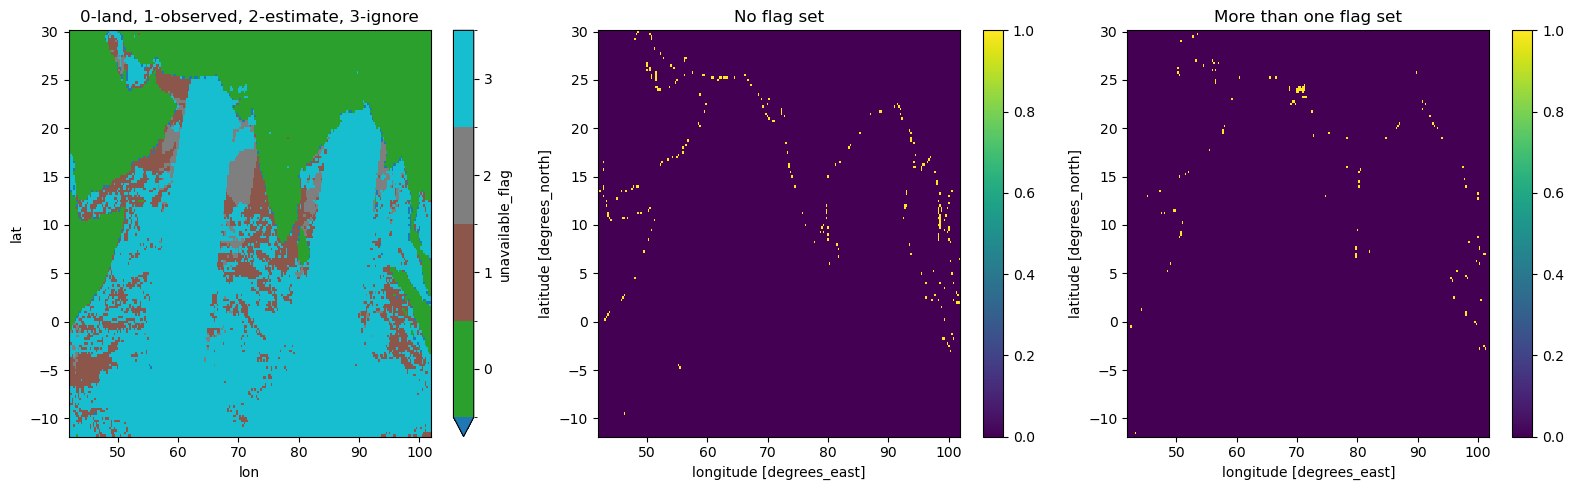

In [16]:
import matplotlib.pyplot as plt
import xarray as xr

t = 20

land = ds_std.land_flag.isel(time=t)
observed = ds_std.observed_flag.isel(time=t)
estimate = ds_std.estimate_flag.isel(time=t)
unavailable = ds_std.unavailable_flag.isel(time=t)

# Count how many flags are set at each pixel
flag_count = land + observed + estimate + unavailable

# Category map:
# 0 = land
# 1 = observed
# 2 = estimate
# 3 = unavailable
category = xr.full_like(land, fill_value=-1, dtype="int8")
category = xr.where(land == 1, 0, category)
category = xr.where(observed == 1, 1, category)
category = xr.where(estimate == 1, 2, category)
category = xr.where(unavailable == 1, 3, category)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

category.plot(
    ax=axes[0],
    levels=[-0.5, 0.5, 1.5, 2.5, 3.5],
    cmap="tab10",
    cbar_kwargs={"ticks": [0, 1, 2, 3]},
)
axes[0].set_title("0-land, 1-observed, 2-estimate, 3-ignore")

(flag_count == 0).plot(ax=axes[1])
axes[1].set_title("No flag set")

(flag_count > 1).plot(ax=axes[2])
axes[2].set_title("More than one flag set")

plt.tight_layout()

In [22]:
land = ds_std.land_flag.isel(time=t).astype("int8").compute()
observed = ds_std.observed_flag.isel(time=t).astype("int8").compute()
estimate = ds_std.estimate_flag.isel(time=t).astype("int8").compute()
unavailable = ds_std.unavailable_flag.isel(time=t).astype("int8").compute()

flag_count = land + observed + estimate + unavailable

combo = (
    1 * land
    + 2 * observed
    + 4 * estimate
    + 8 * unavailable
)

vals, counts = np.unique(
    combo.where(flag_count > 1).values,
    return_counts=True,
)

names = {
    3: "land + observed",
    5: "land + estimate",
    6: "observed + estimate",
    7: "land + observed + estimate",
    9: "land + unavailable",
    10: "observed + unavailable",
    11: "land + observed + unavailable",
    12: "estimate + unavailable",
    13: "land + estimate + unavailable",
    14: "observed + estimate + unavailable",
    15: "all four",
}

for v, n in zip(vals, counts):
    if not np.isnan(v):
        print(f"{names[int(v)]:35s} {n}")

land + observed                     51
land + unavailable                  69


## 3. Train the Model

`mtg.train_model()` runs the full pipeline: `prepare_model_data`, the xbatcher streaming tiler, the fully-convolutional `mtg.UNet`, and the fit loop configured by `options`. It returns a `TrainingResult`.

In [ ]:
# The streaming train/validation pipeline (xbatcher tiling + tf.data) is built
# inside mtg.train_model below, so there is no separate make_generator step
# here. To build the datasets by hand instead, call
# mtg.make_generator(ds_std, options) directly.

The channel count, U-Net architecture, and fit configuration are all taken from the resolved `options`, so the bundle and the fitting pipeline cannot diverge.

In [ ]:
# mtg.train_model builds the fully-convolutional mtg.UNet for you from the
# resolved channel count. To build it by hand instead, call
# mtg.UNet((None, None, len(options.data.input_names)), tile_size=...).

Train with bounded memory: data is streamed one tile at a time.

In [6]:
# Train the model end to end. mtg.train_model runs prepare_model_data, sets up
# the xbatcher streaming pipeline, builds mtg.UNet, and fits it with options.fit
# (optimizer, learning rate, loss, EarlyStopping). It returns a TrainingResult:
#   result.model    - the fitted model
#   result.options  - the resolved configuration (single source of truth)
#   result.metrics  - final validation metrics (val_loss, val_mae)
#   result.history  - epoch-by-epoch training history (dict of lists)
#   result.metadata - resolved run provenance (package version, device, ...)
result = mtg.train_model(ds, options, load_data=True)

model = result.model
history = result.history
print(result.summary())

Split method: random (train=400, val=100 dates)
Training period: 2010-01-10 to 2019-12-22
Channels created (9 total):
  1. observed_target
  2. observed_target_m1
  3. observed_target_p1
  4. day_sin
  5. day_cos
  6. estimate_flag
  7. unavailable_flag
  8. observed_flag
  9. land_flag
Target standardization: mean=0.0000, std=1.0000
Dataset is LAZY (not in memory): Frozen({'time': (98, 98, 98, 98, 108), 'lat': (64, 64, 40), 'lon': (64, 64, 64, 48)})
Streaming datasets ready (batch size 16): steps per epoch train=150, val=37

Model input shape: (batch, 64, 64, 9)
Model output shape: (batch, 64, 64, 1)

Input names: ['observed_target', 'observed_target_m1', 'observed_target_p1', 'day_sin', 'day_cos', 'estimate_flag', 'unavailable_flag', 'observed_flag', 'land_flag']
Starting training: epochs=50, batch_size=16, patience=10
Epoch 1/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 24s 91ms/step - loss: 0.0936 - mae: 0.1601 - val_loss: 0.0421 - val_mae: 0.1046
Epoch 2/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 13s 90m

## 6. Visualize Training History

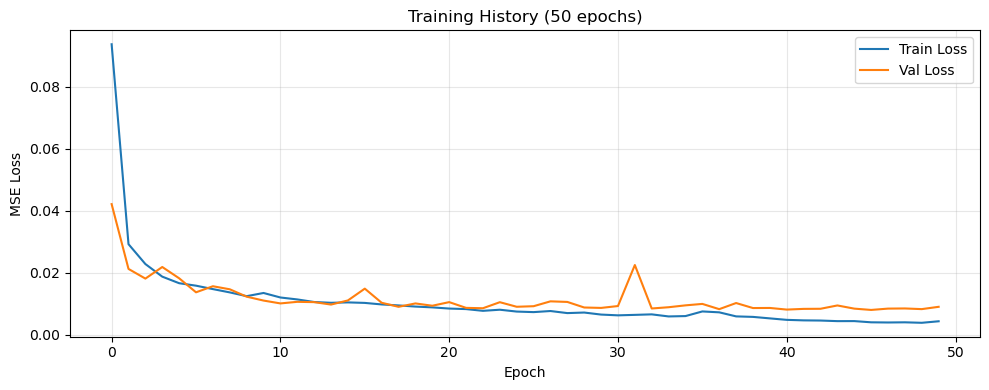


Best epoch: 46
Best val_loss: 0.007992


In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))

epochs_run = len(history['loss'])
ax.plot(history['loss'], label='Train Loss')
ax.plot(history['val_loss'], label='Val Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title(f'Training History ({epochs_run} epochs)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nBest epoch: {np.argmin(history['val_loss']) + 1}")
print(f"Best val_loss: {min(history['val_loss']):.6f}")

## 7. Test Prediction (Full Domain)

Load one test frame and predict on the full domain to verify the model works.

## Making a prediction

Currently the model does not use a custom loss and under clouds, the target is 0 (nan replaced with 0). So the model learns that if there is a real cloud (real_cloud_flag is 1) then predict 0 always. The model also learns that if synthetic _cloud = 0 and real_cloud = 0, then there is a value in masked_target and use that. If synthetic _cloud = 1 and real_cloud = 0, then there is always a 0 in masked_target (non-informative) so make an estimate from the other input variables. 

Soo, that means if we make a prediction from ds_test, it will have 0s whereever there are real clouds and it will only make estimates under the synthetic clouds.

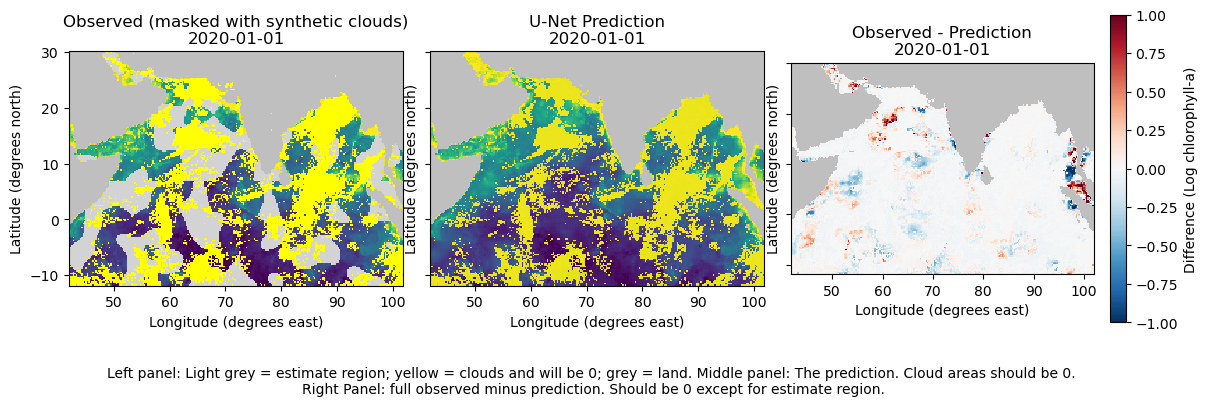

In [32]:
# Pick a test day: the last date in the record that was not used for training
# or validation, falling back to the final available day.
used = set(options.split.train_dates) | set(options.split.val_dates)
available = [str(pd.to_datetime(t).date()) for t in ds.time.values]
unused = [d for d in available if d not in used]
test_date = unused[-1] if unused else available[-1]
print(f"Test prediction date: {test_date}")

# Select and load test frame
ds_std = mtg.prepare_model_data(ds, options, mode="test")
ds_test = ds_std.sel(time=test_date)

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharex=True, sharey=True)

observed = np.nan_to_num(
    ds_test['observed_target'].values,
    nan=0.0
)
full_observed = np.nan_to_num(
    ds_test['full_target'].values,
    nan=0.0
)
estimate = ds_test['estimate_flag'].values.astype(bool)
ignore = ds_test['unavailable_flag'].values.astype(bool)
land = ds_test['land_flag'].values.astype(bool)

# Left panel: observed data only
observed_plot = np.ma.masked_where(
    land | estimate | ignore | ~np.isfinite(observed),
    observed
)

# Middle panel: prediction
prediction = np.ma.masked_where(land, y_pred_orig)

# Right panel: full observed - prediction
diff = full_observed - prediction
diff = np.ma.masked_where(land, diff)

# Geographic coordinates
longitude = ds_test['lon'].values
latitude = ds_test['lat'].values

# Same color scale for observed and prediction
vmin, vmax = np.nanpercentile(
    observed_plot.filled(np.nan),
    [2, 98]
)

plot_kwargs = dict(
    cmap='viridis',
    shading='auto',
    vmin=vmin,
    vmax=vmax
)

# Symmetric color scale for difference
diff_lim = np.nanpercentile(
    np.abs(diff.filled(np.nan)),
    98
)

# ------------------------------------------------------------------
# LEFT PANEL: observed
# ------------------------------------------------------------------

axes[0].set_facecolor('0.75')  # land = grey

axes[0].pcolormesh(
    longitude,
    latitude,
    observed_plot,
    **plot_kwargs
)

# estimate = light grey
estimate_layer = np.ma.masked_where(
    ~estimate,
    np.ones_like(observed, dtype=float)
)

axes[0].pcolormesh(
    longitude,
    latitude,
    estimate_layer,
    cmap=ListedColormap(['lightgrey']),
    shading='auto'
)

# ignore = yellow
ignore_layer = np.ma.masked_where(
    ~ignore,
    np.ones_like(observed, dtype=float)
)

axes[0].pcolormesh(
    longitude,
    latitude,
    ignore_layer,
    cmap=ListedColormap(['yellow']),
    shading='auto'
)

axes[0].set_title(
    f'Observed (masked with synthetic clouds)\n{test_date}'
)

# ------------------------------------------------------------------
# MIDDLE PANEL: prediction
# ------------------------------------------------------------------

axes[1].set_facecolor('0.75')

im = axes[1].pcolormesh(
    longitude,
    latitude,
    prediction,
    **plot_kwargs
)

axes[1].set_title(
    f'U-Net Prediction\n{test_date}'
)

# ------------------------------------------------------------------
# RIGHT PANEL: difference
# ------------------------------------------------------------------

axes[2].set_facecolor('0.75')

im_diff = axes[2].pcolormesh(
    longitude,
    latitude,
    diff,
    cmap='RdBu_r',
    shading='auto',
    vmin=-1, # ca 70% decrease
    vmax=1
)

axes[2].set_title(
    f'Observed - Prediction\n{test_date}'
)

# ------------------------------------------------------------------
# Formatting
# ------------------------------------------------------------------

for ax in axes:
    ax.set_xlabel('Longitude (degrees east)')
    ax.set_ylabel('Latitude (degrees north)')
    ax.set_aspect('equal')

color_label = (
    'Log chlorophyll-a'
    if options.data.log_target
    else 'Chlorophyll-a'
)

# Separate colorbar for difference
plt.colorbar(
    im_diff,
    ax=axes[2],
    label=f'Difference ({color_label})',
    fraction=0.046
)

fig.subplots_adjust(
    wspace=0.08,
    right=0.88,
    bottom=0.15
)

fig.text(
    0.5,
    0.06,
    'Left panel: Light grey = estimate region; yellow = clouds and will be 0; grey = land. '
    'Middle panel: The prediction. Cloud areas should be 0. \nRight Panel: full observed minus prediction. Should be 0 except for estimate region.',
    ha='center',
    va='bottom',
    fontsize=10
)

plt.show()

Test prediction date: 2020-01-01
Channels created (9 total):
  1. observed_target
  2. observed_target_m1
  3. observed_target_p1
  4. day_sin
  5. day_cos
  6. estimate_flag
  7. unavailable_flag
  8. observed_flag
  9. land_flag
Target standardization: mean=0.0000, std=1.0000
Dataset is LAZY (not in memory): Frozen({'time': (100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 100, 53), 'lat': (64, 64, 40), 'lon': (64, 64, 64, 48)})


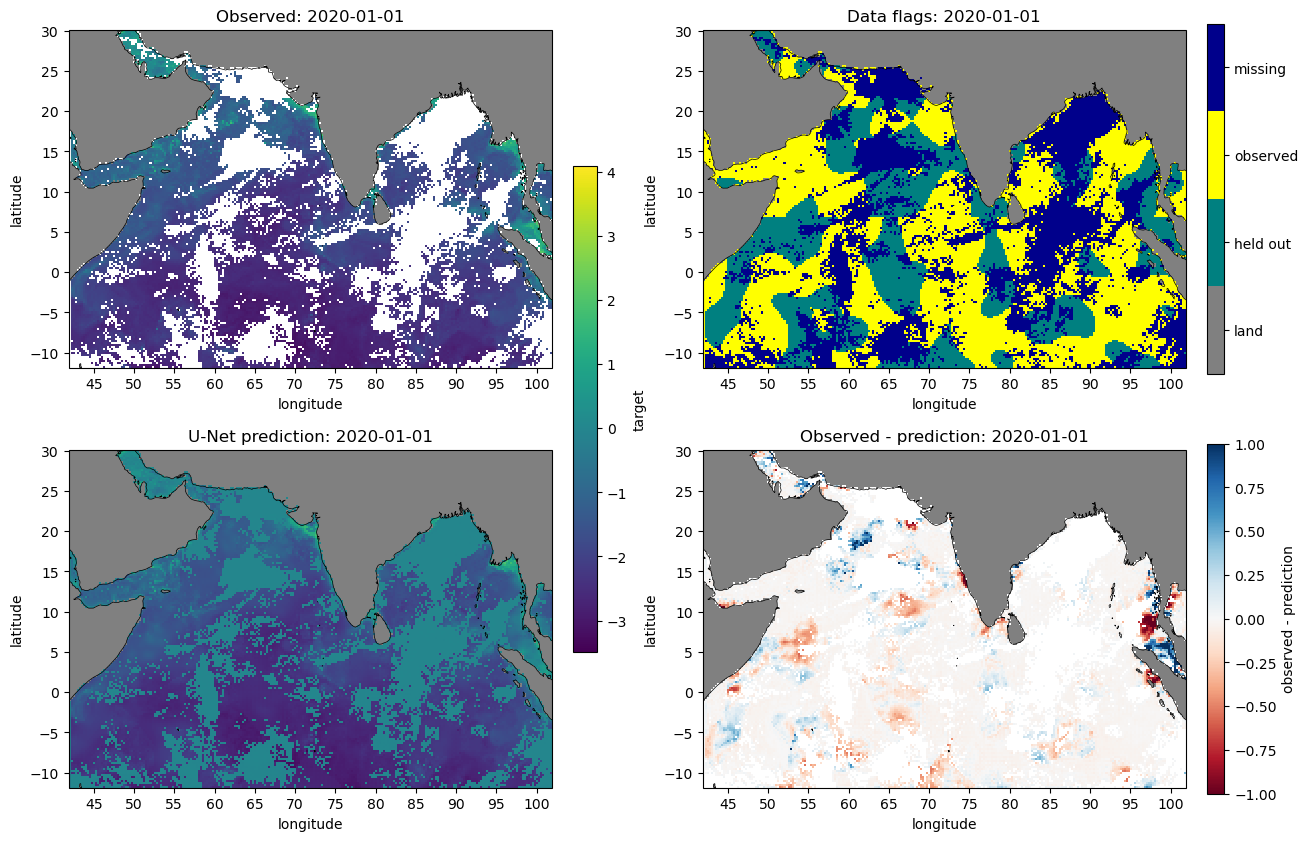

In [34]:
from mindthegap import viz

# Pick a test day: the last date in the record that was not used for training
# or validation, falling back to the final available day.
used = set(options.split.train_dates) | set(options.split.val_dates)
available = [str(pd.to_datetime(t).date()) for t in ds.time.values]
unused = [d for d in available if d not in used]
test_date = unused[-1] if unused else available[-1]
print(f"Test prediction date: {test_date}")

# Select test frame
ds_std = mtg.prepare_model_data(ds, options, mode="test")

fig, axes = viz.plot_prediction_observed(
    ds_std,
    model,
    options,
    test_date,
    difference_limit=1.0,
)
plt.show()

## 8. Save Model

Save the trained model for later use.

In [35]:
# Everything the bundle needs is already resolved on options.data, so the
# bundle and the fitting pipeline cannot diverge. save_model_bundle takes the
# TrainingResult from mtg.train_model and writes model.keras, options.json (the
# single source of truth for how the model was set up), metrics.json (the run's
# metrics/metadata/history for experiment tracking), and README.md. The one
# thing options does not capture is how the raw dataset was built, so record that
# data-creation block via dataset_script; it is copied verbatim into
# make_dataset.py.
from pathlib import Path

data_creation_script = """dataset = "io-shared-public"
region = "indian ocean"
time_slice = slice("01-01-2010", "01-01-2020")

ds, target, missing_flag, land_flag = mtg.demo_data(
    dataset,
    region=region,
    time_slice=time_slice,
    smoke_test=False,
)
"""

bundle_path = Path("../models") / f"{dataset}-unet-bundle"
mtg.save_model_bundle(
    result,
    bundle_path,
    limitations=(
        "Validated only for the documented product, region, training period, "
        "channel order, and preprocessing configuration."
    ),
    dataset_script=data_creation_script,
    overwrite=True,
)
print(f"✓ Model bundle saved to: {bundle_path}")

✓ Model bundle saved to: ../models/io-shared-public-unet-bundle


### Review the saved bundle

The bundle directory now contains `model.keras`, `options.json`, and a `README.md` model card. Open `README.md` and `options.json` and confirm the dataset, region, training period, input channel order, transforms, and standardization values. `options.json` is the single source of truth used to reload and replay the model.

In [36]:
# Verify that the released artifact loads without rebuilding the U-Net.
loaded_model, loaded_options = mtg.load_model_bundle(bundle_path)
round_trip_input = X_test[:1]
expected = model(round_trip_input, training=False).numpy()
actual = loaded_model(round_trip_input, training=False).numpy()
np.testing.assert_allclose(actual, expected, rtol=1e-6, atol=1e-6)
assert loaded_options.data.input_names == options.data.input_names
print("✓ Bundle reload produced equivalent predictions")

Data loaded for this model with: demo_data(dataset='io-shared-public', region='indian ocean', time_slice=slice('01-01-2010', '01-01-2020'))
✓ Bundle reload produced equivalent predictions
